In [1]:
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
from Labeling import *
from purged_cv_by_date import *
import lightgbm as lgbm

## Extract Trading Dates and Prices

In [2]:
with open("./Data/stocks.pkl", "rb") as file: 
    stocks = pkl.load(file)

In [3]:
prices = stocks[["PERMNO", "Date", "DlyClose"]]
prices = prices.set_index(["Date", "PERMNO"], drop=True)
prices = prices.loc[~prices.index.duplicated(keep='first'), :]
prices

,,DlyClose
Date,PERMNO,
2013-01-02,10026,64.3200
2013-01-03,10026,64.6800
2013-01-04,10026,64.7700
2013-01-07,10026,63.4007
2013-01-08,10026,63.4300
...,...,...
2023-12-22,93429,175.5300
2023-12-26,93429,173.6900
2023-12-27,93429,175.6100


## Read in Side-labeled Data

In [4]:
with open("./Data/feature_scores_events.pkl", "rb") as file:
    data = pkl.load(file)

In [5]:
data.describe()

,Date,PERMNO,ma_5,ema_5,slope_ma_5,ma_10,ema_10,slope_ma_10,ma_20,ema_20,...,pv_corr,pv_divergence,label,DlyClose,timestamp,End Time,Return,trade_days,Return_dly,Side
count,688224,688224.000000,688224.000000,688224.000000,688224.000000,688224.000000,688224.000000,688224.000000,688224.000000,688224.000000,...,688224.000000,688224.000000,688224.000000,688224.000000,688224,688224,688224.000000,688224.000000,688224.000000,688224.000000
mean,2018-08-07 20:21:03.063188480,66195.741782,0.006251,0.006304,0.007949,0.006261,0.006244,-0.002353,0.006197,0.006096,...,0.003224,-0.003224,0.002897,57.610769,2018-08-07 20:21:03.063188480,2018-08-12 07:04:26.522527744,0.002202,4.059103,0.000593,0.012258
min,2013-04-04 00:00:00,10026.000000,-1.025310,-1.025152,-7.088935,-1.024847,-1.024539,-6.734629,-1.024029,-1.022825,...,-2.491097,-3.332061,-0.950092,0.040600,2013-04-04 00:00:00,2013-04-05 00:00:00,-0.903307,2.000000,-0.400972,-1.000000
25%,2015-11-24 00:00:00,38093.000000,-0.619627,-0.619671,-0.387763,-0.619814,-0.619955,-0.377465,-0.620055,-0.620458,...,-0.754614,-0.732845,-0.022691,13.020000,2015-11-24 00:00:00,2015-12-02 00:00:00,-0.025090,2.000000,-0.007515,-1.000000
50%,2018-08-14 00:00:00,81621.000000,-0.317590,-0.317421,-0.013043,-0.317315,-0.317345,-0.027073,-0.316977,-0.317004,...,-0.026778,0.026778,0.001392,31.920000,2018-08-14 00:00:00,2018-08-17 00:00:00,0.007318,3.000000,0.001453,0.000000
75%,2021-05-11 00:00:00,89708.000000,0.260188,0.260132,0.387345,0.260470,0.260658,0.355186,0.261000,0.260913,...,0.732845,0.754614,0.024631,66.670000,2021-05-11 00:00:00,2021-05-13 00:00:00,0.025641,5.000000,0.007610,1.000000
max,2023-12-01 00:00:00,93429.000000,6.124177,6.118742,6.570649,6.104151,6.095153,6.785469,6.084156,6.061786,...,3.332061,2.491097,208.852217,3696.060000,2023-12-01 00:00:00,2023-12-21 00:00:00,103.187192,16.000000,20.637438,1.000000
std,NaN,30127.982968,1.002969,1.003000,1.089839,1.002969,1.002965,1.028496,1.002867,1.002767,...,1.012377,1.012377,0.319197,110.095093,NaN,NaN,0.169074,2.569951,0.049418,0.804423


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 688224 entries, 0 to 688223
Data columns (total 58 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Date                688224 non-null  datetime64[ns]
 1   PERMNO              688224 non-null  int64         
 2   ma_5                688224 non-null  float64       
 3   ema_5               688224 non-null  float64       
 4   slope_ma_5          688224 non-null  float64       
 5   ma_10               688224 non-null  float64       
 6   ema_10              688224 non-null  float64       
 7   slope_ma_10         688224 non-null  float64       
 8   ma_20               688224 non-null  float64       
 9   ema_20              688224 non-null  float64       
 10  slope_ma_20         688224 non-null  float64       
 11  ma_60               688224 non-null  float64       
 12  ema_60              688224 non-null  float64       
 13  slope_ma_60         688224 no

In [7]:
data.columns

Index(['Date', 'PERMNO', 'ma_5', 'ema_5', 'slope_ma_5', 'ma_10', 'ema_10',
       'slope_ma_10', 'ma_20', 'ema_20', 'slope_ma_20', 'ma_60', 'ema_60',
       'slope_ma_60', 'ret_1', 'ret_5', 'ret_10', 'ret_20', 'macd_dif',
       'macd_dea', 'macd', 'macd_cross', 'bb_mid', 'bb_upper', 'bb_lower',
       'bb_pctB', 'rsi', 'rsv_10', 'rsv_20', 'aroon_up_10', 'aroon_down_10',
       'aroon_up_20', 'aroon_down_20', 'range_hl_over_c', 'atr', 'gap_oc_prev',
       'gap_cc_prev', 'shadow_upper_ratio', 'shadow_lower_ratio', 'ret_c2c',
       'ret_co', 'ret_oc', 'vol', 'adv', 'dvol', 'vol_z', 'turnover_proxy',
       'vwap_proxy', 'pv_corr', 'pv_divergence', 'label', 'DlyClose',
       'timestamp', 'End Time', 'Return', 'trade_days', 'Return_dly', 'Side'],
      dtype='object')

In [8]:
data["Side"].value_counts()

Side
 0.0    242774
 1.0    226943
-1.0    218507
Name: count, dtype: int64

## 1.1 Hyperparameter Tuning

In [ ]:
data_cv = data[(data["Date"]>= "2016-01-01") & (data["Date"]<= "2017-01-01")]

In [ ]:
#drop forward looking columns from Features
Label_cols = ['PERMNO','label', 'DlyClose', 'timestamp', 'End Time', 'Return', 'trade_days', 'Return_dly', 'Side']
X_cv = data_cv.drop(columns=Label_cols)
y_cv = data_cv["Side"]

In [ ]:
#iterable Hyperparameter Combinations
cv_params = {'max_depth': [3, 5, 7, 10, 15, -1],  #树最大深度，-1 表示不限制深度
             'n_estimators': [100, 200, 300],     #树的棵树数（boosting 轮数）
             'learning_rate': [0.01, 0.05, 0.1]   #学习率
             }  

params_comb = param_grid_dicts(cv_params)

In [139]:
import lightgbm as lgb
from sklearn.metrics import f1_score, log_loss  #f1_score：分类 F1 分数; log_loss：多分类 log loss（对概率输出的损失）

n_samples = X_cv.shape[0]
n_splits = 5

folds = purged_kfold_indices_by_date(n_samples = n_samples , n_splits= n_splits, purge_size=20)

results = []

for params in params_comb:

    weighted_f1_scores = []
    log_loss_cv = [] 

    for fold, (train_idx, test_idx) in enumerate(folds, 1):
        
        # Extract training and test data for this fold.
        X_t, y_t = X_cv.iloc[train_idx , : ], y_lgbm[train_idx]
        X_val, y_val = X_cv.iloc[test_idx, : ], y_lgbm[test_idx]

        # Fit the model using Lightgbm.
        lgbm = lgb.LGBMClassifier(
                            objective='multiclass',
                            num_class=3,
                            **params,
                            num_leaves=32,
                            random_state=42,
                            )

        #fit model using early stopping.
        lgbm.fit(X_t,
                 y_t,
                 eval_set=[(X_val, y_val)],
                 eval_metric='multi_logloss',
                 callbacks=[
                     lgb.log_evaluation(period=10),
                     lgb.early_stopping(stopping_rounds=50) #early stopping; 这样当验证集 log loss 连续 50 轮没有改善时，就会停止训练
                 ]
        )

        #compute 
        y_pred = lgbm.predict(X_val)
        weighted_f1 = f1_score(y_pred=y_pred, y_true=y_val, average="weighted")
        weighted_f1_scores.append(weighted_f1)

        preds = lgbm.predict_proba(X_val)
        log_loss_cv.append(log_loss(y_val, preds,labels=[0, 1, 2]))


    mean_F1 = np.mean(weighted_f1_scores)
    mean_log_loss = np.mean(log_loss_cv)
    
    result_entry = {
        **params,
        "weighted F1" : mean_F1,
        "avg_log_loss" : mean_log_loss,
    }
    results.append(result_entry)

    print(f"mean F1 Score: {mean_F1},  mean Log Loss: {mean_log_loss}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000608 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 51685, number of used features: 23
[LightGBM] [Info] Start training from score -0.773887
[LightGBM] [Info] Start training from score -0.618442
[LightGBM] [Info] Start training from score -34.538776
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

In [141]:
df_results = pd.DataFrame(results)

In [143]:
df_results

,max_depth,n_estimators,learning_rate,weighted F1,avg_log_loss
0,3,100,0.10,0.517475,18.966289
1,3,200,0.01,0.451352,18.965595
2,3,200,0.05,0.516309,18.966184
3,3,200,0.10,0.534344,18.967728
4,3,300,0.01,0.461818,18.965492
5,3,300,0.05,0.527293,18.966994
6,3,300,0.10,0.538961,18.968356
7,5,100,0.01,0.450028,18.965181
8,5,100,0.05,0.528539,18.966492
9,5,100,0.10,0.540848,18.968683


## 1.2 Train Primary Model with purged CV - Random Forest

In [54]:
Label_cols = ['PERMNO','label', 'DlyClose', 'timestamp', 'End Time', 'Return', 'trade_days', 'Return_dly', 'Side']

In [55]:
data = data.sort_values("Date").reset_index(drop = True)

X_TRAIN = data.loc[data['Date'] < '2021-01-01'].copy()
X_TEST  = data.loc[data['Date'] >= '2021-04-01'].copy() #Introduce Purging into Training and Test Set - no leakage

In [56]:
X_tr = X_TRAIN.drop(columns = Label_cols)
Y_tr = X_TRAIN["Side"]

In [57]:
from sklearn.metrics import classification_report, f1_score

# Fit the Primary model on the Training Data only to create out-of-sample prediction using predicition and probabilities on test set using purged CV
# for the Side Label that is later used in the meta model.
n_samples = X_tr.shape[0]
n_splits = 5

folds = purged_kfold_indices_by_date(
    df=X_tr,
    n_splits=n_splits,
    purge_days=60
)

#Now drop Date
X_tr = X_tr.drop(columns = ["Date"])  
y_tr = Y_tr


# Arrays for out-of-sample prediction and Probability for each Label
oof_proba = np.zeros((n_samples, len(np.unique(y_tr)))) # class probabilities
oof_pred  = np.zeros(n_samples)  # hard labels

for fold, (train_idx, val_idx) in enumerate(folds, 1):
    
    print(f"Fold {fold}")

    X_t, y_t = X_tr.iloc[train_idx , : ], y_tr.iloc[train_idx]
    X_val, y_val = X_tr.iloc[val_idx, : ], y_tr.iloc[val_idx]
    
    # Fit the model using Lightgbm.
    primary = lgbm.LGBMClassifier(
                        objective='multiclass',
                        num_class=3,
                        max_depth = 5,
                        n_estimators = 300, 
                        learning_rate = 0.05,
                        num_leaves=32,
                        random_state=42,
                        )

    #fit model using early stopping.
    primary.fit(X_t,
                y_t,
                eval_set=[(X_val, y_val)],
                eval_metric='multi_logloss',
                callbacks=[
                    lgbm.log_evaluation(period=10),
                    lgbm.early_stopping(stopping_rounds=50) #early stopping; 这样当验证集 log loss 连续 50 轮没有改善时，就会停止训练
                ]
    )

    # Out-of-sample predictions for this fold
    proba_val = primary.predict_proba(X_val)
    pred_val = primary.predict(X_val)

    oof_proba[val_idx, :] = proba_val
    oof_pred[val_idx]     = pred_val

    weighted_F1 = f1_score(y_true=y_val, y_pred=pred_val, average="weighted")
    print(f"OOF weighted F1: {weighted_F1:.4f}")


avg_confidence = np.mean(np.max(oof_proba, axis=1))
print(f"OOF average confidence: {avg_confidence:.4f}")

print(classification_report(y_tr, oof_pred))

Fold 1
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019204 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12240
[LightGBM] [Info] Number of data points in the train set: 382199, number of used features: 48
[LightGBM] [Info] Start training from score -1.167675
[LightGBM] [Info] Start training from score -1.008228
[LightGBM] [Info] Start training from score -1.126870
Training until validation scores don't improve for 50 rounds
[10]	valid_0's multi_logloss: 0.990705
[20]	valid_0's multi_logloss: 0.950711
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[30]	valid_0's multi_logloss: 0.928619
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [58]:
X_TRAIN.loc[:,"pred_Side"] = oof_pred
X_TRAIN.loc[:,"pred_Side_proba"] = np.max(oof_proba, axis=1)

In [59]:
#Check Label Assignment
equal = (X_TRAIN["Side"] == X_TRAIN["pred_Side"]).sum()
accuracy = equal / len(X_TRAIN["Side"])
accuracy

np.float64(0.5370167380208977)

## 1.4 Fit Primary Model on complete Training Dataset

In [60]:
Drop = Label_cols + ["Date", "pred_Side" ,"pred_Side_proba"]

X_train_full_primary = X_TRAIN.drop(columns=Drop)
Y_train_full_primary = X_TRAIN["Side"].values

# Fit the model using Lightgbm.
primary_full = lgbm.LGBMClassifier(
                    objective='multiclass',
                    num_class=3,
                    max_depth = 5,
                    n_estimators = 300, 
                    learning_rate = 0.05,
                    #num_leaves=32,
                    random_state=42,
                    )

#fit model using early stopping.
primary_full.fit(X_train_full_primary,
            Y_train_full_primary,
            eval_metric='multi_logloss',
)

primary_full.fit(X_train_full_primary, Y_train_full_primary) 

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025691 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12240
[LightGBM] [Info] Number of data points in the train set: 493547, number of used features: 48
[LightGBM] [Info] Start training from score -1.209174
[LightGBM] [Info] Start training from score -0.951299
[LightGBM] [Info] Start training from score -1.154175
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 1.5 Feature Importance

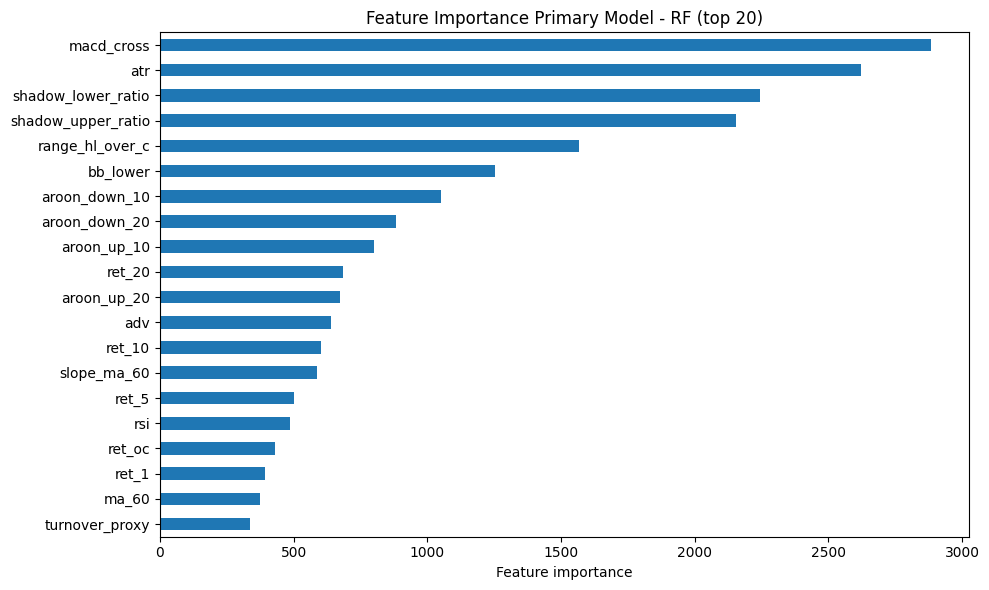

In [61]:
importances = primary_full.feature_importances_
feat_imp = pd.Series(importances, index=X_train_full_primary.columns).sort_values(ascending=False)
feat_imp_20 = feat_imp.head(20)

plt.figure(figsize=(10, 6))
feat_imp_20[::-1].plot(kind="barh")  # reverse to get largest at top
plt.xlabel("Feature importance")
plt.title(f"Feature Importance Primary Model - RF (top {20})")
plt.tight_layout()
plt.show()

## Train Secondary Model

In [62]:
permno_list = X_TRAIN["PERMNO"].unique()

In [63]:
data_indexed = X_TRAIN.set_index(["Date", "PERMNO"], drop=False)
data_indexed = data_indexed.sort_index(level=0)

In [64]:
from Labeling import meta_labeling
# Based on the Out of Sample Prediction for the Training Data obtained using pruged CV,
# label the event [1,0] if profitable or not.
data_meta_dict = {}

for id in permno_list:
    
    data_sub = data_indexed.xs(id, level="PERMNO").sort_index()
    prices_sub = prices.xs(id, level="PERMNO").sort_index()

    labels = meta_labeling(data_sub, prices_sub["DlyClose"], threshold=0.4)
    
    labeled_events = pd.merge(data_sub, labels, left_index=True, right_index=True)
    data_meta_dict[id] = labeled_events

In [65]:
X_TRAIN = pd.concat(data_meta_dict, ignore_index=True)

In [66]:
X_TRAIN.columns

Index(['Date', 'PERMNO', 'ma_5', 'ema_5', 'slope_ma_5', 'ma_10', 'ema_10',
       'slope_ma_10', 'ma_20', 'ema_20', 'slope_ma_20', 'ma_60', 'ema_60',
       'slope_ma_60', 'ret_1', 'ret_5', 'ret_10', 'ret_20', 'macd_dif',
       'macd_dea', 'macd', 'macd_cross', 'bb_mid', 'bb_upper', 'bb_lower',
       'bb_pctB', 'rsi', 'rsv_10', 'rsv_20', 'aroon_up_10', 'aroon_down_10',
       'aroon_up_20', 'aroon_down_20', 'range_hl_over_c', 'atr', 'gap_oc_prev',
       'gap_cc_prev', 'shadow_upper_ratio', 'shadow_lower_ratio', 'ret_c2c',
       'ret_co', 'ret_oc', 'vol', 'adv', 'dvol', 'vol_z', 'turnover_proxy',
       'vwap_proxy', 'pv_corr', 'pv_divergence', 'label', 'DlyClose',
       'timestamp', 'End Time', 'Return', 'trade_days', 'Return_dly', 'Side',
       'pred_Side', 'pred_Side_proba', 'Return of Label', 'Label'],
      dtype='object')

In [67]:
X_TRAIN["Label"].value_counts()

Label
0.0    385174
1.0    108373
Name: count, dtype: int64

In [68]:
#include predicted Side and Probabilities in Meta Model
Drop = Label_cols + ["Date", "Return of Label", "Label"]
X_meta = X_TRAIN.drop(columns=Drop)

Y_meta = X_TRAIN["Label"].values

In [69]:
# Fit the model using Lightgbm.
secondary = lgbm.LGBMClassifier(
                    objective='multiclass',
                    num_class=3,
                    max_depth = 5,
                    n_estimators = 300, 
                    learning_rate = 0.05,
                    #num_leaves=32,
                    random_state=42,
                    )

#fit model using early stopping.
secondary.fit(X_meta,
            Y_meta,
            eval_metric='multi_logloss',
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.028587 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12498
[LightGBM] [Info] Number of data points in the train set: 493547, number of used features: 50
[LightGBM] [Info] Start training from score -0.247923
[LightGBM] [Info] Start training from score -1.516039
[LightGBM] [Info] Start training from score -34.538776
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


# 3. Prediction on Held Out Test Set

In [70]:
X_TEST.columns

Index(['Date', 'PERMNO', 'ma_5', 'ema_5', 'slope_ma_5', 'ma_10', 'ema_10',
       'slope_ma_10', 'ma_20', 'ema_20', 'slope_ma_20', 'ma_60', 'ema_60',
       'slope_ma_60', 'ret_1', 'ret_5', 'ret_10', 'ret_20', 'macd_dif',
       'macd_dea', 'macd', 'macd_cross', 'bb_mid', 'bb_upper', 'bb_lower',
       'bb_pctB', 'rsi', 'rsv_10', 'rsv_20', 'aroon_up_10', 'aroon_down_10',
       'aroon_up_20', 'aroon_down_20', 'range_hl_over_c', 'atr', 'gap_oc_prev',
       'gap_cc_prev', 'shadow_upper_ratio', 'shadow_lower_ratio', 'ret_c2c',
       'ret_co', 'ret_oc', 'vol', 'adv', 'dvol', 'vol_z', 'turnover_proxy',
       'vwap_proxy', 'pv_corr', 'pv_divergence', 'label', 'DlyClose',
       'timestamp', 'End Time', 'Return', 'trade_days', 'Return_dly', 'Side'],
      dtype='object')

In [71]:
Drop = Label_cols + ["Date"]

X_test = X_TEST.drop(columns=Drop)
Y_train = X_TEST["Side"].values

In [72]:
# Primary predictions on held-out test
side_proba= primary_full.predict_proba(X_test)
side_pred = primary_full.predict(X_test)

In [73]:
X_test.loc[: , "pred_Side"] = side_pred
X_test.loc[: , "pred_Side_proba"] = np.max(side_proba, axis=1)

X_TEST.loc[: , "pred_Side"] = side_pred
X_TEST.loc[: , "pred_Side_proba"] = np.max(side_proba, axis=1)

In [74]:
label = secondary.predict(X_test)
label_prob = np.max(secondary.predict_proba(X_test) , axis = 1) 

In [75]:
X_TEST.loc[: , "pred_Label"] = label
X_TEST.loc[: , "pred_Label_proba"] = label_prob
X_TEST

,Date,PERMNO,ma_5,ema_5,slope_ma_5,ma_10,ema_10,slope_ma_10,ma_20,ema_20,...,timestamp,End Time,Return,trade_days,Return_dly,Side,pred_Side,pred_Side_proba,pred_Label,pred_Label_proba
509927,2021-04-01,78223,-0.138926,-0.136838,-0.063952,-0.129153,-0.133423,-0.276364,-0.130969,-0.125183,...,2021-04-01,2021-04-13,0.026479,8,0.003310,1.0,-1.0,0.394910,0.0,0.999947
509928,2021-04-01,14702,0.602683,0.613751,4.190594,0.553706,0.573040,4.679005,0.510909,0.533978,...,2021-04-01,2021-04-12,-0.046071,7,-0.006582,-1.0,-1.0,0.492055,1.0,0.502562
509929,2021-04-01,78975,3.142024,3.182581,4.410730,3.200442,3.209838,3.608831,3.298951,3.273688,...,2021-04-01,2021-04-08,0.040710,5,0.008142,1.0,-1.0,0.357641,0.0,0.999944
509930,2021-04-01,13681,-0.364182,-0.364537,-0.222704,-0.365717,-0.365914,0.058289,-0.371287,-0.363678,...,2021-04-01,2021-04-07,0.040844,4,0.010211,1.0,-1.0,0.484987,1.0,0.513168
509931,2021-04-01,92614,0.776518,0.779215,0.714990,0.767968,0.770085,1.878300,0.743578,0.771476,...,2021-04-01,2021-04-13,0.032007,8,0.004001,1.0,0.0,0.613975,0.0,0.999325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688219,2023-12-01,93137,-0.223136,-0.223627,-0.012312,-0.224509,-0.223257,-0.189870,-0.221737,-0.221573,...,2023-12-01,2023-12-04,0.011747,2,0.005874,0.0,0.0,0.882044,0.0,0.999960
688220,2023-12-01,12462,-0.502166,-0.502746,-0.036072,-0.503788,-0.503578,-0.242851,-0.504656,-0.505972,...,2023-12-01,2023-12-13,0.038360,9,0.004262,1.0,1.0,0.355200,0.0,0.999937
688221,2023-12-01,89282,-0.581576,-0.582704,-0.243123,-0.582124,-0.582751,-0.394883,-0.583773,-0.585431,...,2023-12-01,2023-12-06,-0.009346,4,-0.002336,0.0,0.0,0.487957,0.0,0.998350
688222,2023-12-01,11752,-0.315631,-0.315514,0.286385,-0.319218,-0.319158,0.125711,-0.325594,-0.326466,...,2023-12-01,2023-12-04,0.025641,2,0.012821,1.0,-1.0,0.511569,1.0,0.534143


In [76]:
X_TEST["pred_Side"].value_counts()

pred_Side
 0.0    69225
 1.0    68263
-1.0    40809
Name: count, dtype: int64

In [77]:
with open('./Data/scores_test_side_meta_labeled_lgbm.pkl', 'wb') as file:
    pkl.dump(X_TEST, file)

# Backtesting the Strategy


We now have all predictions on the Test set
Recap: Meta_Label is set based on a minimal profit of 2% at event endtime, so model should try to learn/focus on events with actual return.

Test the following Strategy: 
- Leverage the Label Probability to determine Trades to take and compute return of that strategy.

In [113]:
with open('./Data/scores_test_side_meta_labeled_lgbm.pkl', 'rb') as file:
    X_backtest = pkl.load(file)

In [115]:
def return_of_Label(
    events: pd.DataFrame,
    Label_prob = 0.7,
) -> pd.DataFrame:

    events_filtered = events.dropna(subset=['End Time'])
    out = pd.DataFrame(index=events_filtered.index)

    out["Date"] = events_filtered["Date"]

    #Return of Label = positive if sign of return equal predicted Side and vice versa
    out['Return of Label'] = events_filtered["Return"] * events_filtered['pred_Side']

    #return of each event
    out["event_ret"] = out['Return of Label'] * events_filtered['pred_Label']

    #If Probability to Trade less then threshold set value to zero --> No Trade
    out.loc[(events_filtered["pred_Label_proba"] <= Label_prob), "event_ret"] = 0
    
    out["event_ret_dly"] = out["event_ret"] / events_filtered["trade_days"]

    return out

In [116]:
df_results = return_of_Label(X_backtest)

In [117]:
df_results

,Date,Return of Label,event_ret,event_ret_dly
509927,2021-04-01,-0.026479,-0.0,-0.0
509928,2021-04-01,0.046071,0.0,0.0
509929,2021-04-01,-0.040710,-0.0,-0.0
509930,2021-04-01,-0.040844,0.0,0.0
509931,2021-04-01,0.000000,0.0,0.0
...,...,...,...,...
688219,2023-12-01,0.000000,0.0,0.0
688220,2023-12-01,0.038360,0.0,0.0
688221,2023-12-01,-0.000000,-0.0,-0.0
688222,2023-12-01,-0.025641,0.0,0.0


In [118]:
# Basic stats
df_backtest = df_results[df_results["event_ret"] != 0]

In [119]:
# Basic stats
mean_ret_daily = df_backtest["event_ret_dly"].mean()
mean_ret = df_backtest["event_ret"].mean()

event_std_ret  = df_backtest["event_ret"].std()
std_ret_daily = df_backtest["event_ret_dly"].std()

n_trades = df_backtest.shape[0]

# Annualized Sharpe (assuming event frequency ~ daily)
sharpe = mean_ret_daily / std_ret_daily * np.sqrt(252) if std_ret_daily > 0 else np.nan

print(f"Out-of-sample trades: {n_trades}, Total number of Out-of_sample events: {df_results.shape[0]}")
print(f"Mean event return: {mean_ret:.6f}")
print(f"Mean daily event return: {mean_ret_daily:.6f}")
print(f"Std event return:  {std_ret_daily:.6f}")
print(f"Annualized Sharpe: {sharpe:.3f}")

Out-of-sample trades: 1598, Total number of Out-of_sample events: 178297
Mean event return: 0.003416
Mean daily event return: 0.001622
Std event return:  0.014604
Annualized Sharpe: 1.763


In [120]:
daily_ret = (
    df_backtest
    .groupby("Date")["event_ret_dly"]
    .mean()
    .sort_index()
)

# 累计收益曲线（简单收益）
equity_curve = (1 + daily_ret).cumprod()

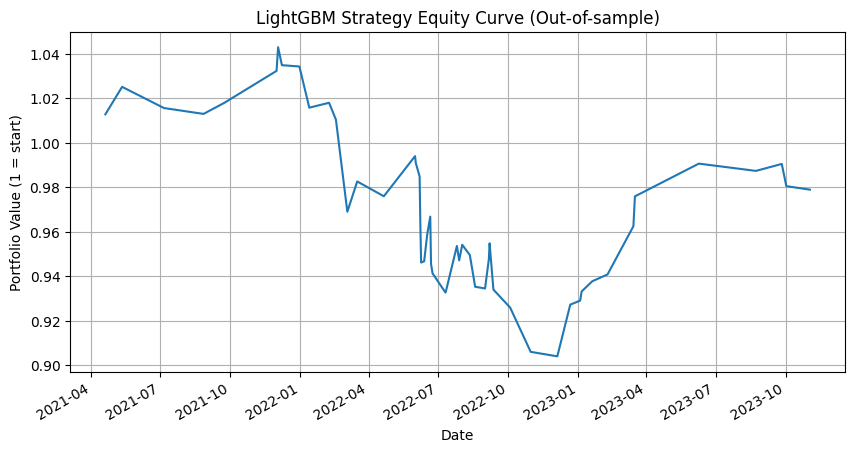

In [133]:
plt.figure(figsize=(10, 5))
equity_curve.plot()
plt.title("LightGBM Strategy Equity Curve (Out-of-sample)")
plt.ylabel("Portfolio Value (1 = start)")
plt.xlabel("Date")
plt.grid(True)
plt.show()

In [122]:
mu_d = daily_ret.mean()
sigma_d = daily_ret.std()

# 每年交易天数
annual_factor = 252

annual_return = (1 + mu_d)**annual_factor - 1
annual_vol    = sigma_d * np.sqrt(annual_factor)
sharpe        = annual_return / annual_vol

In [123]:
cum_curve = (1 + daily_ret).cumprod()
cum_max = cum_curve.cummax()
drawdown = cum_curve / cum_max - 1
max_dd = drawdown.min()
win_rate = (daily_ret > 0).mean()

In [124]:
perf = pd.Series({
    "Annual Return": annual_return,
    "Annual Vol": annual_vol,
    "Sharpe": sharpe,
    "Max Drawdown": max_dd,
    "Win Rate (daily)": win_rate,
})
print(perf)

#In the 2017 out-of-sample backtesting, the prediction strategy based on LightGBM achieved an annualized return of approximately 6%,
#with an annualized volatility of only about 5.3%, a maximum drawdown of about 3.3%, an annualized Sharpe ratio of 1.13, and a daily 
#win rate of approximately 52.6%. This indicates that the model does possess a certain predictive ability in directional judgment and 
#can obtain moderate positive returns at a relatively low risk level. However, the overall alpha is limited.

Annual Return      -0.079803
Annual Vol          0.212769
Sharpe             -0.375067
Max Drawdown       -0.133300
Win Rate (daily)    0.490196
dtype: float64


In [ ]:
#Comparison
#The Random Forest model achieved a label prediction accuracy of approximately 54.4%, slightly higher than the LightGBM model 
#(approximately 52.4%). However, at the strategy level, the two differed significantly: the LightGBM strategy achieved an annualized 
#return of approximately 5.97% and an annualized volatility of 5.26% during the backtesting period, corresponding to an annualized
#Sharpe ratio of 1.13 and a maximum drawdown of approximately 3.3%; while the Random Forest strategy had an annualized Sharpe of only 
#approximately 0.38. This indicates that although Random Forest has a slight advantage in classification accuracy, its profit and loss
#distribution is worse, and the losses from mispredictions are greater, making it difficult to translate into attractive risk-adjusted 
#returns.

#Considering both label accuracy and strategy performance, the LightGBM model significantly outperforms Random Forest under the settings 
#of this study and is more suitable as the main model for subsequent strategy optimization and expansion, while Random Forest is more 
#suitable as a control or ensemble component.

## Qijun Part

In [49]:
with open('/Users/qijun/Desktop/MTH628/stocks_labeled.pkl', 'wb') as file:
    stocks = pickle.dump(data_labeled, file)

In [51]:
data_labeled.columns

Index(['ticker', 'PERMNO', 'Date', 'DlyVol', 'DlyClose', 'DlyLow', 'DlyHigh',
       'DlyOpen', 'SMA_20', 'SMA_50', 'EMA_20', 'EMA_50', 'ret_1d', 'ret_5d',
       'ret_10d', 'ret_20d', 'MACD', 'MACD_Signal', 'HL_range', 'Gap_OC',
       'Gap_CC', 'RSI', 'Return', 'Lag_Return_1', 'Lag_Return_2',
       'Lag_Return_3', 'Tomorrow_Return', 'End Time_x', 'Return of Label',
       'Label', 'End Time_y', 'timestamp', 'Side'],
      dtype='object')

In [85]:
import pickle as pkl
import plotly.graph_objects as go

In [87]:
tickers = [
    "AAPL","MSFT","NVDA","GOOGL","GOOG","AMZN","META","BRK/B","LLY",
    "AVGO","JPM","TSLA","JNJ","V","XOM","UNH","WMT","MA","HD","PG"
]

In [89]:
with open("/Users/qijun/Desktop/MTH628/stocks_side_label.pkl", "rb") as file:
    data = pkl.load(file)

In [91]:
subset = data[data['ticker'].isin(tickers)]

In [93]:
subset

,ticker,PERMNO,Date,DlyVol,DlyClose,DlyLow,DlyHigh,DlyOpen,SMA_20,SMA_50,...,Gap_CC,RSI,Return,Lag_Return_1,Lag_Return_2,Lag_Return_3,Tomorrow_Return,End Time,timestamp,Side
95597,AAPL,14593,2013-03-22,14656421.0,461.91,453.1100,462.100,454.58,439.7554,459.33126,...,0.020277,58.090356,0.020074,0.001437,-0.005317,-0.002703,0.003609,2013-03-27,2013-04-11,-1.0
95598,AAPL,14593,2013-03-27,12366736.0,452.08,450.7301,456.800,456.46,441.7782,455.95598,...,-0.019638,50.607790,-0.019834,-0.005286,0.003609,0.020074,-0.021057,2013-03-28,2013-04-16,-1.0
95599,AAPL,14593,2013-04-01,14658907.0,428.91,427.7400,443.698,441.90,441.7632,453.54718,...,-0.031062,38.145106,-0.031555,-0.021057,-0.019834,-0.005286,0.002054,2013-04-15,2013-04-22,-1.0
95600,AAPL,14593,2013-04-10,14200187.0,435.69,426.0100,437.060,428.10,441.5694,446.34552,...,0.020399,46.291156,0.020194,0.001805,0.007087,-0.010624,-0.003126,2013-04-15,2013-04-30,-1.0
95601,AAPL,14593,2013-04-15,12029191.0,419.85,419.5500,427.890,427.00,440.5429,444.61332,...,-0.023150,36.904897,-0.023422,-0.010485,-0.003126,0.020194,0.015105,2013-04-17,2013-05-06,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
672857,AVGO,93002,2023-11-20,1842265.0,995.71,973.0000,999.870,973.00,903.6175,871.35640,...,0.018390,72.187918,0.018222,0.018769,-0.016383,0.002505,-0.014680,2023-11-22,2023-12-11,-1.0
672858,AVGO,93002,2023-11-27,9618385.0,950.24,949.3300,981.010,976.15,927.9405,880.58720,...,-0.029248,56.378992,-0.029684,0.007043,-0.009421,-0.014680,-0.004102,2023-11-30,2023-12-18,-1.0
672859,AVGO,93002,2023-11-30,4889052.0,925.73,918.3700,942.415,941.00,941.8080,886.25000,...,-0.016050,49.409315,-0.016180,-0.005850,-0.004102,-0.029684,0.004602,2023-12-06,2023-12-20,-1.0
672860,AVGO,93002,2023-12-06,2435080.0,903.64,903.1000,920.970,920.36,948.7130,893.91420,...,-0.010382,43.231436,-0.010436,-0.011812,-0.006505,0.004602,0.020396,2023-12-07,2023-12-26,1.0


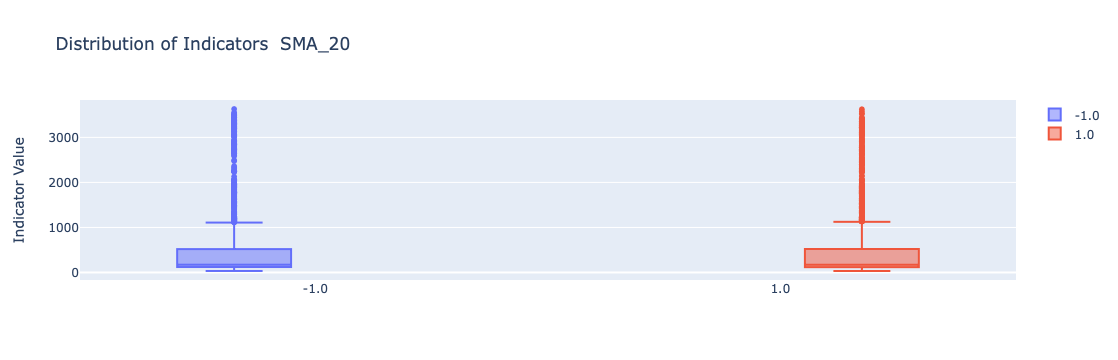

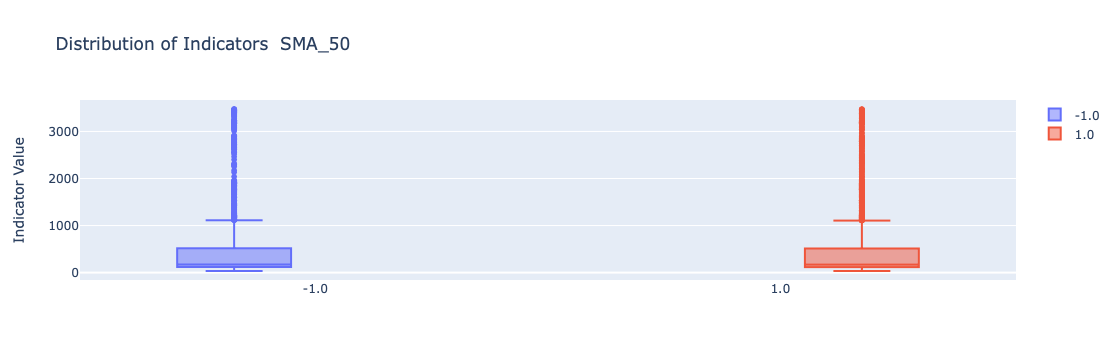

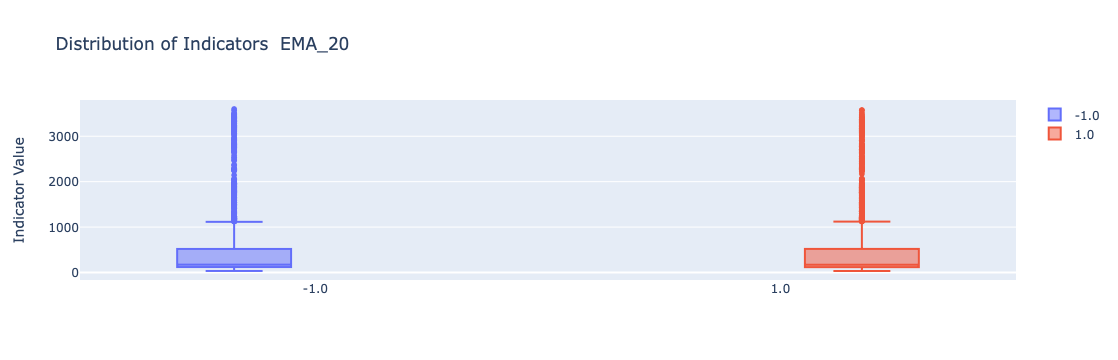

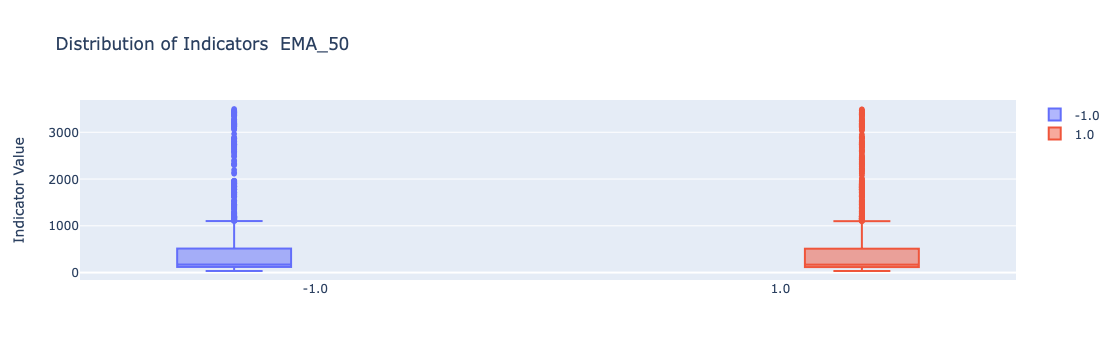

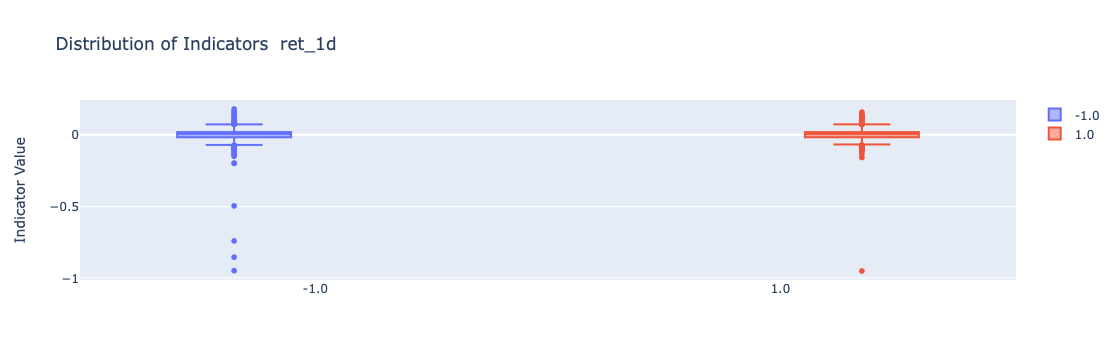

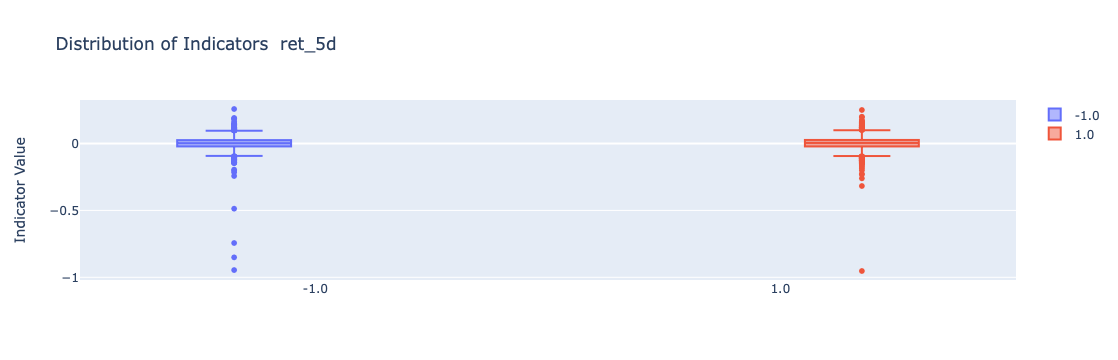

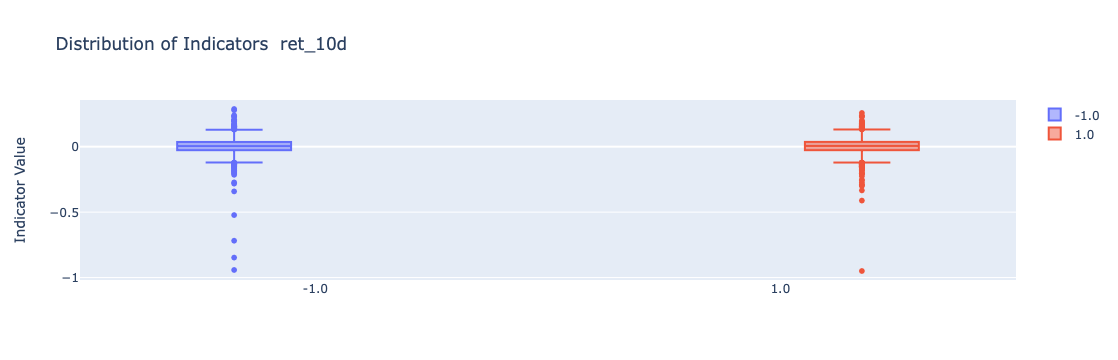

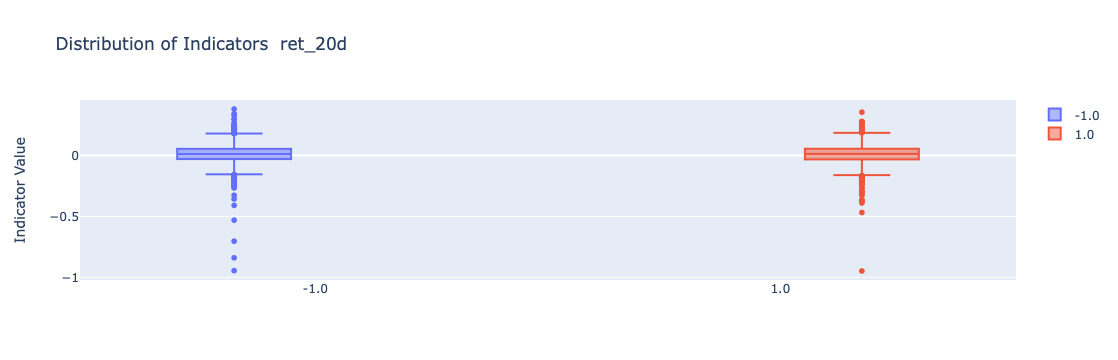

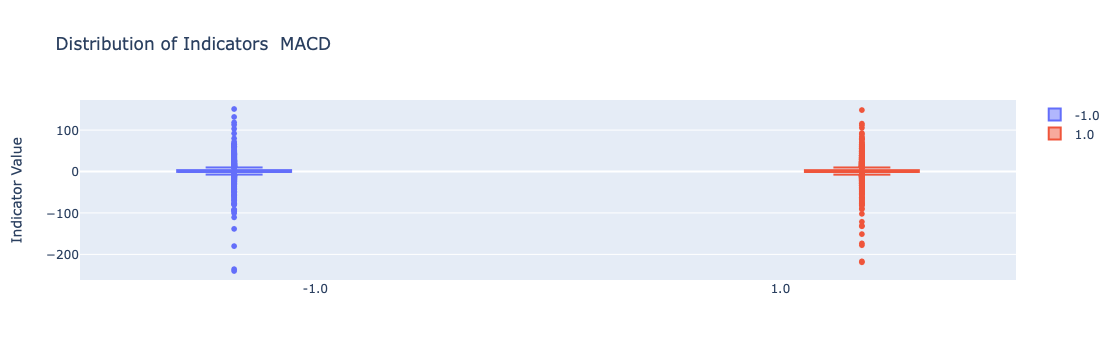

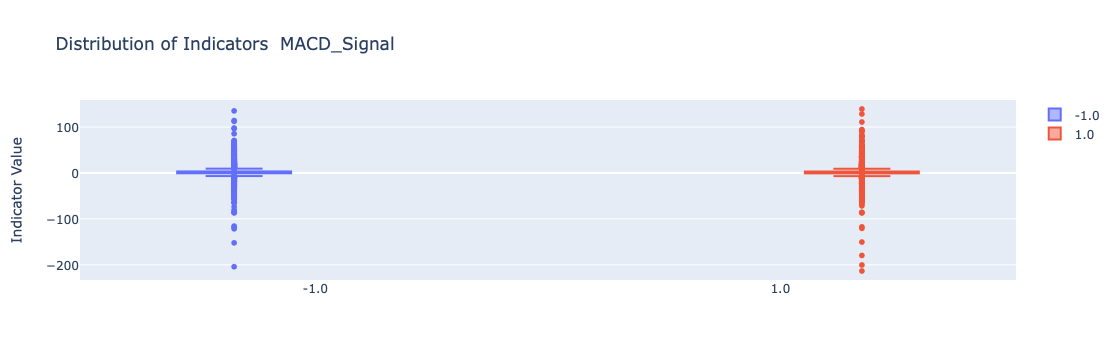

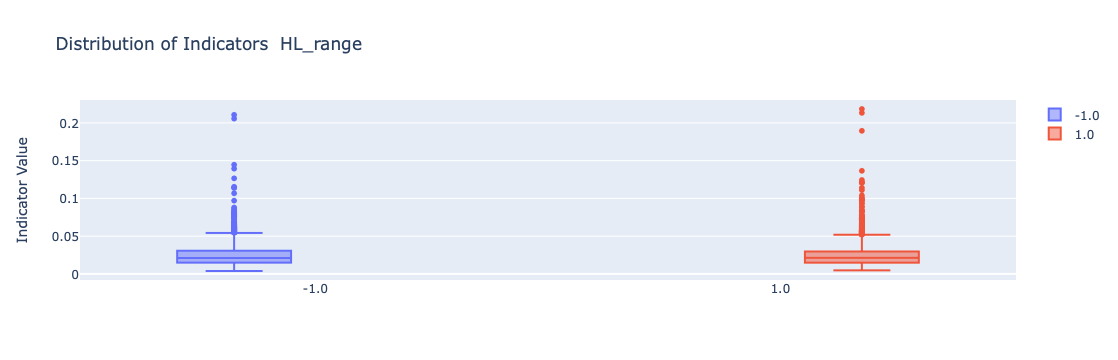

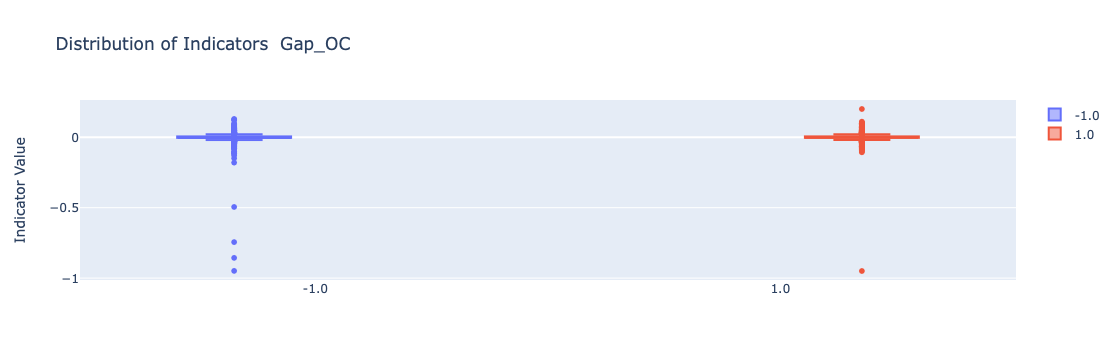

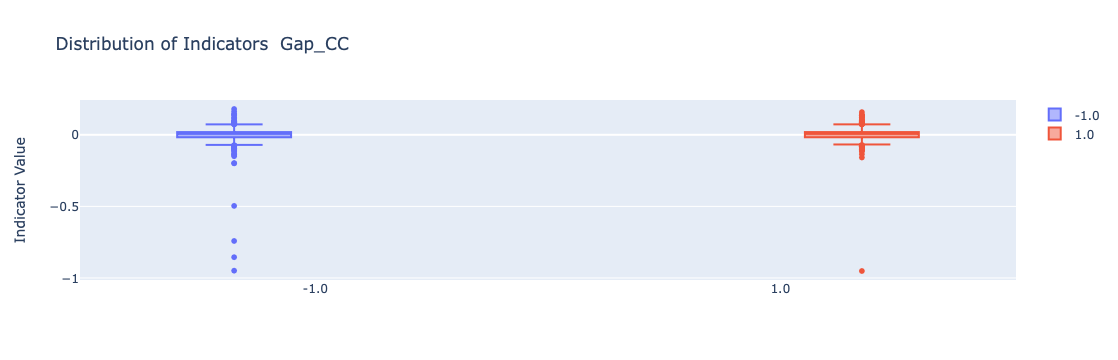

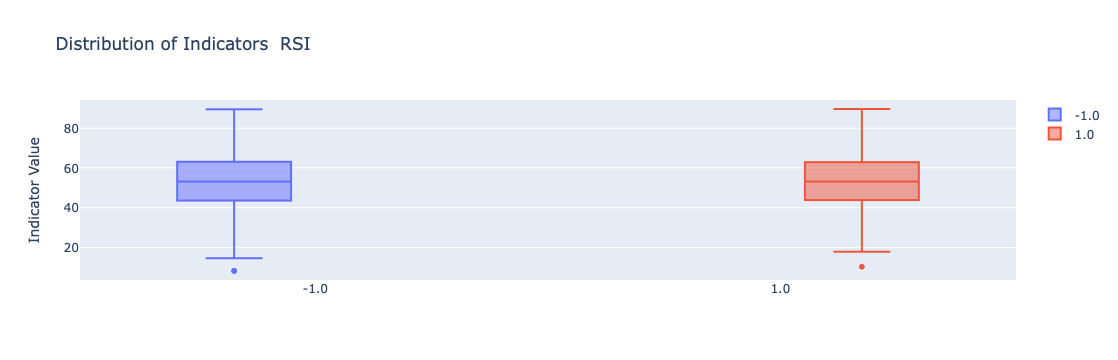

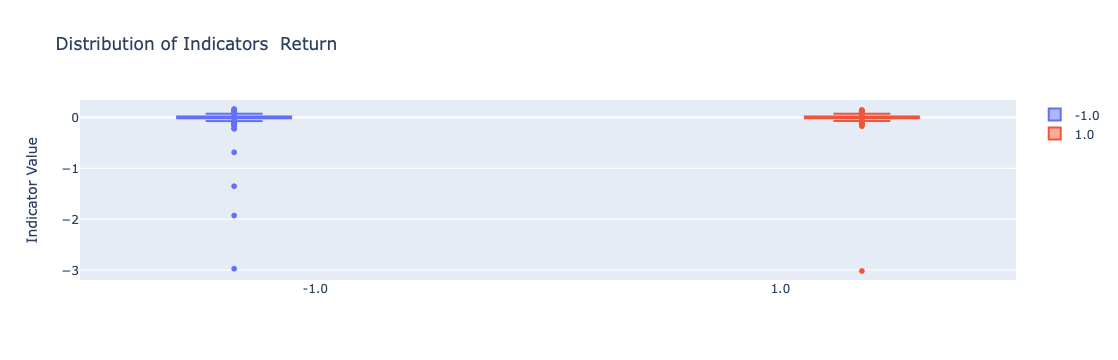

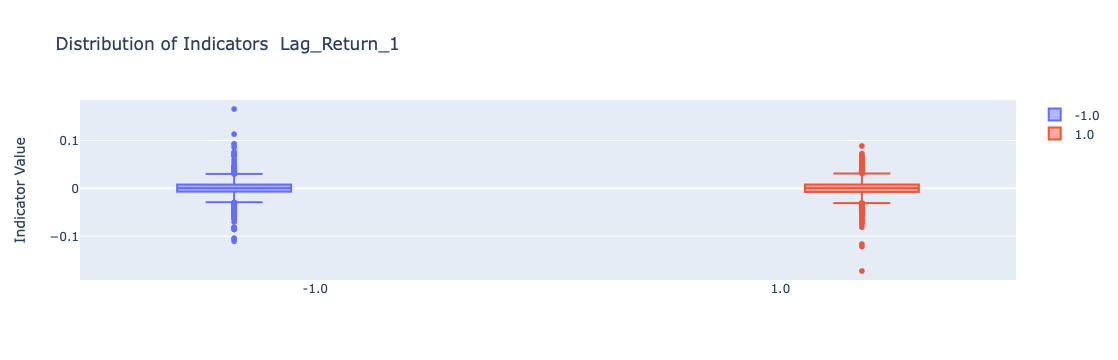

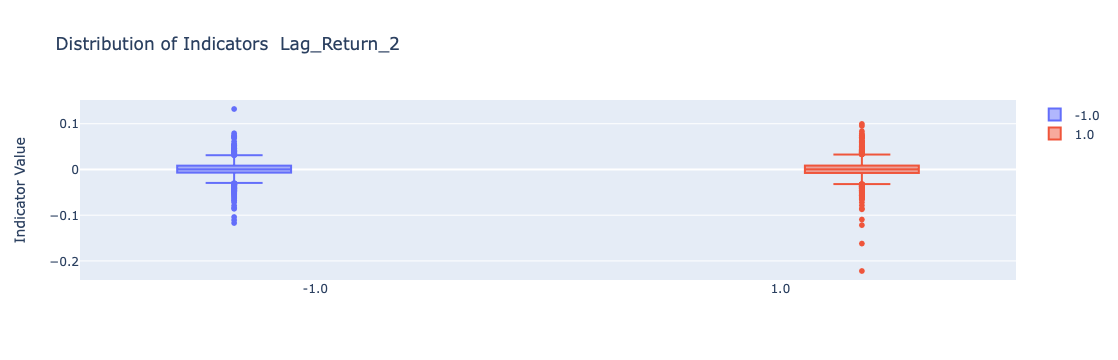

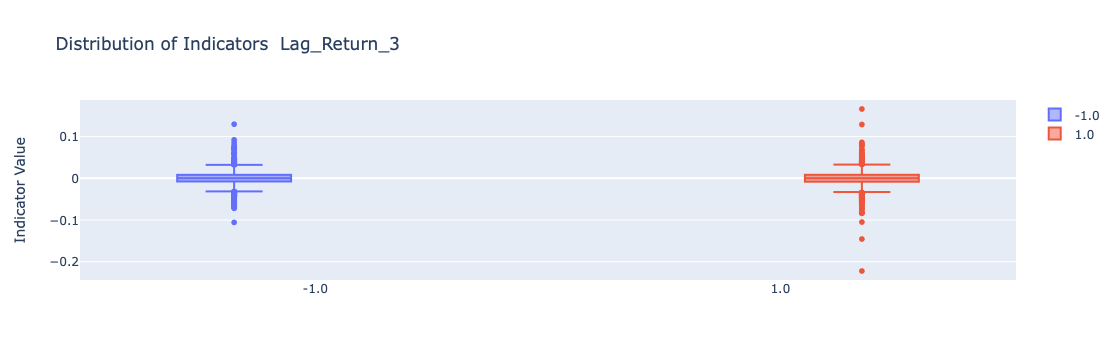

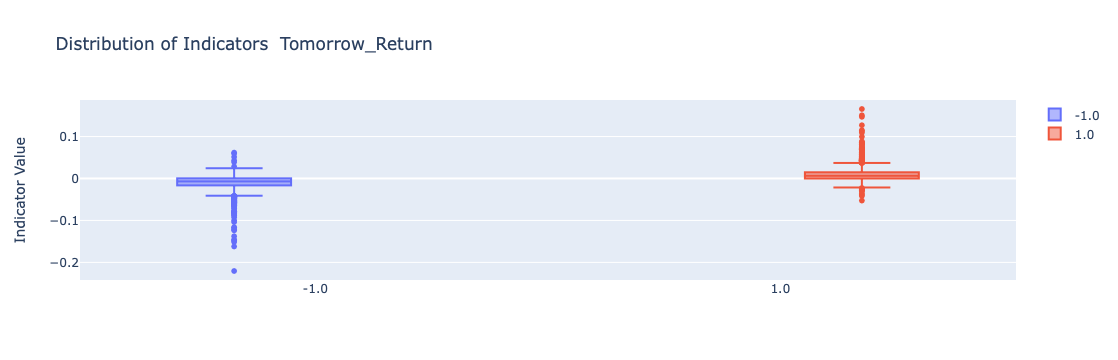

In [99]:
import plotly.graph_objects as go
import pandas as pd

def plot_indicator_distributions(df: pd.DataFrame, indicator_columns: list) -> None:
    """Plots box plots of indicator features for each label."""

    for col in indicator_columns:
        fig = go.Figure()

        for side in df['Side'].unique():
            if side != 0:
              fig.add_trace(go.Box(y=df[df['Side'] == side][col], name=side)) #只保留非 0 的标签来画图，也就是忽略 Label=0 的样本。一般在你前面的 meta-labeling 逻辑里，0 代表“不要交易/不值得跟”的样本，所以这里只看“有交易信号”的例子。
        fig.update_layout(title=f'Distribution of Indicators  {col}',
                         yaxis_title='Indicator Value',
                         boxmode='group')
        fig.show()


indicator_cols = ['SMA_20', 'SMA_50', 'EMA_20', 'EMA_50', 'ret_1d', 'ret_5d',
       'ret_10d', 'ret_20d', 'MACD', 'MACD_Signal', 'HL_range', 'Gap_OC',
       'Gap_CC', 'RSI', 'Return', 'Lag_Return_1', 'Lag_Return_2',
       'Lag_Return_3', 'Tomorrow_Return']

plot_indicator_distributions(subset, indicator_cols)
#遍历 indicator_cols 中的每一个指标;对每个非零 Side 画一个箱线图;显示一张按标签分组的指标分布图




In [109]:
data_cv = data[(data["Date"]>= "2016-01-01") & (data["Date"]<= "2017-01-01")]

In [131]:
#drop forward looking columns from Features
X_cv = data_cv.drop(columns=["ticker","PERMNO", "Date", "End Time", "Side", "Tomorrow_Return", "id", "timestamp"]) #从 data_cv 中丢掉这些列;ticker, PERMNO, Date, id：身份/时间信息，不当作数值特征;End Time, timestamp：事件结束时间 / 垂直障碍的时间，这些是 label 生成过程的中间产物;Side：这是你的原始方向信号，要当作标签;Tomorrow_Return：这是前视信息（未来收益），不能当作输入特征，否则严重泄露未来。剩余的列就是各类技术指标、历史收益等特征。
y_cv = data_cv["Side"]

# Lightgbm expects class labels from 0 to num_class
mapping = {-1: 0, 0: 1, 1: 2} #mapping = {-1: 0, 0: 1, 1: 2}把原来的 3 个类别映射成 0,1,2：原始 -1 → 0;原始 0 → 1;原始 1 → 2
y_mv = y_cv.map(mapping).astype(int) #对 y_cv 中每个值应用映射，得到一个新的 Series；

y_lgbm = y_mv.values #把 Series 转成 numpy 数组，后面喂给 LightGBM

In [121]:
X_cv.columns

Index(['DlyVol', 'DlyClose', 'DlyLow', 'DlyHigh', 'DlyOpen', 'SMA_20',
       'SMA_50', 'EMA_20', 'EMA_50', 'ret_1d', 'ret_5d', 'ret_10d', 'ret_20d',
       'MACD', 'MACD_Signal', 'HL_range', 'Gap_OC', 'Gap_CC', 'RSI', 'Return',
       'Lag_Return_1', 'Lag_Return_2', 'Lag_Return_3'],
      dtype='object')

In [123]:
y_mv.value_counts()

Side
2    34825
0    29807
Name: count, dtype: int64

In [125]:
X_cv.describe()

,DlyVol,DlyClose,DlyLow,DlyHigh,DlyOpen,SMA_20,SMA_50,EMA_20,EMA_50,ret_1d,...,MACD,MACD_Signal,HL_range,Gap_OC,Gap_CC,RSI,Return,Lag_Return_1,Lag_Return_2,Lag_Return_3
count,6.463200e+04,64632.000000,64632.000000,64632.000000,64632.000000,64632.000000,64632.000000,64632.000000,64632.000000,64632.000000,...,64632.000000,64632.000000,64632.000000,64632.000000,64632.000000,64632.000000,64632.000000,64632.000000,64632.000000,64632.000000
mean,1.931002e+06,44.224414,43.558294,44.828014,44.179301,44.174185,44.092328,44.171046,44.057782,0.002101,...,0.040031,0.044005,0.036615,0.000521,0.002101,51.174132,0.000670,0.000477,0.000316,-0.000388
std,6.891373e+06,62.842718,62.054549,63.573014,62.831478,62.808484,62.662208,62.768154,62.511366,0.089504,...,1.366088,1.276776,0.033556,0.089715,0.089504,13.435439,0.047981,0.025973,0.022931,0.025937
min,3.420000e+02,0.067200,0.060000,0.076000,0.071500,0.097050,0.150952,0.110629,0.158293,-0.801945,...,-58.470940,-52.357484,0.000000,-0.799941,-0.801945,5.857022,-1.619208,-1.619208,-0.691244,-1.619208
25%,1.269350e+05,12.467425,12.250000,12.690000,12.480000,12.451875,12.480250,12.461829,12.508981,-0.021130,...,-0.231288,-0.213993,0.017351,-0.005161,-0.021130,41.666607,-0.021357,-0.008577,-0.008938,-0.009597
50%,4.208775e+05,28.210000,27.727500,28.680000,28.185000,28.213375,28.296000,28.258585,28.379873,0.004910,...,0.031003,0.031562,0.027397,0.000000,0.004910,51.364116,0.004898,0.000728,0.000383,0.000000
75%,1.489840e+06,55.560000,54.600000,56.380000,55.422500,55.289750,55.070000,55.332461,55.213141,0.022235,...,0.367754,0.349223,0.044444,0.005457,0.022235,60.769597,0.021991,0.009852,0.009657,0.009155
max,3.750886e+08,838.090000,832.400000,841.290000,841.020000,829.754000,805.556400,821.799709,804.503844,11.578354,...,27.196777,24.848194,1.390830,14.211868,11.578354,98.549751,2.531977,2.531977,0.466460,2.531977


In [127]:
#iterable Hyperparameter Combinations
cv_params = {'max_depth': [3, 5, 7, 10, 15, -1],  #树最大深度，-1 表示不限制深度
             'n_estimators': [100, 200, 300],     #树的棵树数（boosting 轮数）
             'learning_rate': [0.01, 0.05, 0.1]   #学习率
             }  

params_comb = param_grid_dicts(cv_params)

In [147]:
results_df = pd.DataFrame(results)
best_row = results_df.sort_values("weighted F1", ascending=False).iloc[0]
best_params = {
    "max_depth": int(best_row["max_depth"]),
    "n_estimators": int(best_row["n_estimators"]),
    "learning_rate": float(best_row["learning_rate"]),
}
best_params


{'max_depth': 5, 'n_estimators': 300, 'learning_rate': 0.05}

In [149]:
mapping = {-1: 0, 0: 1, 1: 2}
inv_mapping = {0: -1, 1: 0, 2: 1}  # 回映射用

def make_X_y(df: pd.DataFrame):
    """
    给定一个带所有列的数据框，返回：
    X: 特征矩阵
    y_lgbm: 映射到 [0,1,2] 的标签（np.array）
    """
    X = df.drop(columns=[
        "ticker","PERMNO","Date","End Time","Side",
        "Tomorrow_Return","id","timestamp"
    ])
    y = df["Side"]
    y_mv = y.map(mapping).astype(int)
    return X, y_mv.values


In [151]:
# 训练 + CV 区间（和之前一致）
train_mask = (data["Date"] >= "2016-01-01") & (data["Date"] <= "2017-01-01")
data_train = data[train_mask].copy()

# 回测区间：举例用到 2018-01-01，你可以按自己需求改
test_mask = (data["Date"] > "2017-01-01") & (data["Date"] <= "2018-01-01")
data_test = data[test_mask].copy()

X_train, y_train = make_X_y(data_train)
X_test,  y_test  = make_X_y(data_test)

#这里的 y_test 只是用来看预测指标（accuracy / F1 等），策略回测不直接用它，而是用 Tomorrow_Return 来算真实收益。

In [153]:
#用最优参数训练最终模型
import lightgbm as lgb

lgbm_final = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    num_leaves=32,
    random_state=42,
    **best_params,  # 来自 CV 结果
)

lgbm_final.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001499 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 64632, number of used features: 23
[LightGBM] [Info] Start training from score -0.773966
[LightGBM] [Info] Start training from score -0.618374
[LightGBM] [Info] Start training from score -34.538776
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

LGBMClassifier(learning_rate=0.05, max_depth=5, n_estimators=300, num_class=3,
               num_leaves=32, objective='multiclass', random_state=42)

In [155]:
#在回测集上生成预测信号
# 预测类别（0/1/2）
y_pred_test = lgbm_final.predict(X_test)

# 预测概率（如果你想设置信心阈值，也可以用）
y_proba_test = lgbm_final.predict_proba(X_test)


In [159]:
#把预测类别映射回原始的 Side（-1/0/1）：
data_test = data_test.copy()
data_test["Side_pred_class"] = y_pred_test
data_test["Side_pred"] = data_test["Side_pred_class"].map(inv_mapping)

#现在 data_test 中每一行都有：Side：原始标签（真值方向，可以用于评估分类精度）；Side_pred：模型预测的交易方向（-1：做空，0：不交易，1：做多）。

In [163]:
#把信号变成收益：单笔 & 按天聚合
#在日期 t，根据特征预测 Side_pred(t)，从 t 收盘买入/卖出，持有到 t+1，这期间的标的收益就是 Tomorrow_Return(t)，策略收益就等于：
#策略收益(t) = Side_pred(t) * Tomorrow_Return(t)

# 单资产单事件收益（这里一行 = 某日某股票的一笔信号）
data_test["strategy_ret"] = data_test["Side_pred"] * data_test["Tomorrow_Return"]


In [165]:
# 按 Date 把所有股票等权合成一个“组合”
daily_ret = (
    data_test
    .groupby("Date")["strategy_ret"]
    .mean()
    .sort_index()
)

# 累计收益曲线（简单收益）
equity_curve = (1 + daily_ret).cumprod()


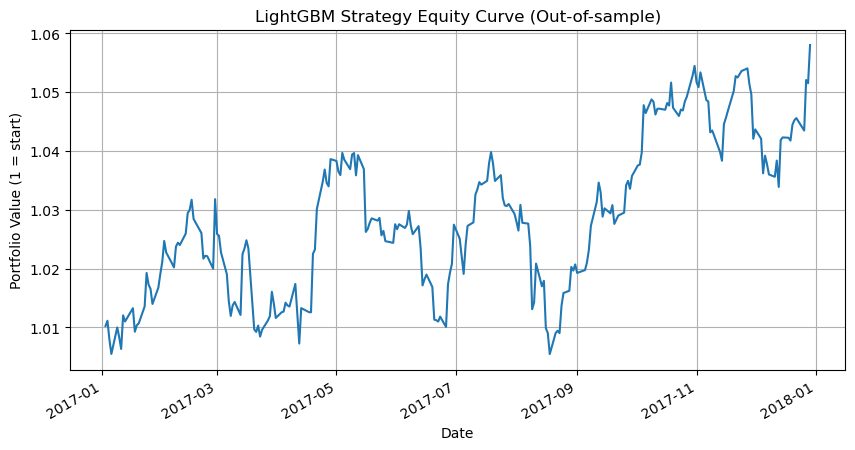

In [169]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
equity_curve.plot()
plt.title("LightGBM Strategy Equity Curve (Out-of-sample)")
plt.ylabel("Portfolio Value (1 = start)")
plt.xlabel("Date")
plt.grid(True)
plt.show()

#conclusion on the chart:
#这条 LightGBM 策略的净值曲线 整体略微向上，回撤不大，说明模型确实学到了一些有用的方向信息，但 alpha 规模并不惊艳。
#从研究角度，它是一个“有效但还不够强”的 baseline，适合作为后续改进（特征工程、meta-labeling、仓位/阈值优化、与其他因子叠加）的起点。

#图示表达的内容：
#从 1 元起步，把每天所有股票的策略收益等权平均，然后把这些日收益连续乘起来，得到组合净值。

#整体表现
#起点：1.00 左右；终点：大约 1.055–1.06，说明这段回测区间的 总收益约 5–6%；时间跨度差不多一年，所以这是 年化 ~5–6% 的策略（未考虑交易成本和滑点）。

#风险侧：最大回撤 & 波动的直观感受
#最大回撤大约发生在 5–8 月，大致从 1.038 掉到 1.01 左右，约 –2.5%～–3%
#年化收益 ~5–6%，最大回撤 ~–3%，在不考虑交易成本的理想条件下，这是个 收益温和、回撤也比较可控 的曲线；

#模型特点：
#有一定方向性预测能力；在平均意义上，模型预测的多/空方向是偏对的。
#alpha 不算大
#明显存在 regime：好做的时期 & 难做的时期
#模型没有崩盘迹象

In [181]:
#年化收益 & 年化波动 & Sharpe

# 日平均收益 & 方差
mu_d = daily_ret.mean()
sigma_d = daily_ret.std()

# 每年交易天数
annual_factor = 252

annual_return = (1 + mu_d)**annual_factor - 1
annual_vol    = sigma_d * np.sqrt(annual_factor)
sharpe        = annual_return / annual_vol


In [183]:
cum_curve = (1 + daily_ret).cumprod()
cum_max = cum_curve.cummax()
drawdown = cum_curve / cum_max - 1
max_dd = drawdown.min()
win_rate = (daily_ret > 0).mean()
perf = pd.Series({
    "Annual Return": annual_return,
    "Annual Vol": annual_vol,
    "Sharpe": sharpe,
    "Max Drawdown": max_dd,
    "Win Rate (daily)": win_rate,
})
print(perf)

#In the 2017 out-of-sample backtesting, the prediction strategy based on LightGBM achieved an annualized return of approximately 6%,
#with an annualized volatility of only about 5.3%, a maximum drawdown of about 3.3%, an annualized Sharpe ratio of 1.13, and a daily 
#win rate of approximately 52.6%. This indicates that the model does possess a certain predictive ability in directional judgment and 
#can obtain moderate positive returns at a relatively low risk level. However, the overall alpha is limited.

from sklearn.metrics import accuracy_score

label_acc_num = accuracy_score(y_test, y_pred_test)

print(f"Out-of-sample trades: {len(y_test)}")
print(f"accuracy of predicted labels (numeric 0/1/2): {label_acc_num:.4f}")


In [185]:
win_rate = (daily_ret > 0).mean()


In [187]:
perf = pd.Series({
    "Annual Return": annual_return,
    "Annual Vol": annual_vol,
    "Sharpe": sharpe,
    "Max Drawdown": max_dd,
    "Win Rate (daily)": win_rate,
})
print(perf)

#In the 2017 out-of-sample backtesting, the prediction strategy based on LightGBM achieved an annualized return of approximately 6%,
#with an annualized volatility of only about 5.3%, a maximum drawdown of about 3.3%, an annualized Sharpe ratio of 1.13, and a daily 
#win rate of approximately 52.6%. This indicates that the model does possess a certain predictive ability in directional judgment and 
#can obtain moderate positive returns at a relatively low risk level. However, the overall alpha is limited.

Annual Return       0.059699
Annual Vol          0.052623
Sharpe              1.134469
Max Drawdown       -0.033017
Win Rate (daily)    0.525896
dtype: float64


In [199]:
from sklearn.metrics import accuracy_score

label_acc_num = accuracy_score(y_test, y_pred_test)

print(f"Out-of-sample trades: {len(y_test)}")
print(f"accuracy of predicted labels (numeric 0/1/2): {label_acc_num:.4f}")


Out-of-sample trades: 61449
accuracy of predicted labels (numeric 0/1/2): 0.5244


In [ ]:
#Comparison
#The Random Forest model achieved a label prediction accuracy of approximately 54.4%, slightly higher than the LightGBM model 
#(approximately 52.4%). However, at the strategy level, the two differed significantly: the LightGBM strategy achieved an annualized 
#return of approximately 5.97% and an annualized volatility of 5.26% during the backtesting period, corresponding to an annualized
#Sharpe ratio of 1.13 and a maximum drawdown of approximately 3.3%; while the Random Forest strategy had an annualized Sharpe of only 
#approximately 0.38. This indicates that although Random Forest has a slight advantage in classification accuracy, its profit and loss
#distribution is worse, and the losses from mispredictions are greater, making it difficult to translate into attractive risk-adjusted 
#returns.

#Considering both label accuracy and strategy performance, the LightGBM model significantly outperforms Random Forest under the settings 
#of this study and is more suitable as the main model for subsequent strategy optimization and expansion, while Random Forest is more 
#suitable as a control or ensemble component.

AUC (Up vs Down) = 0.4980


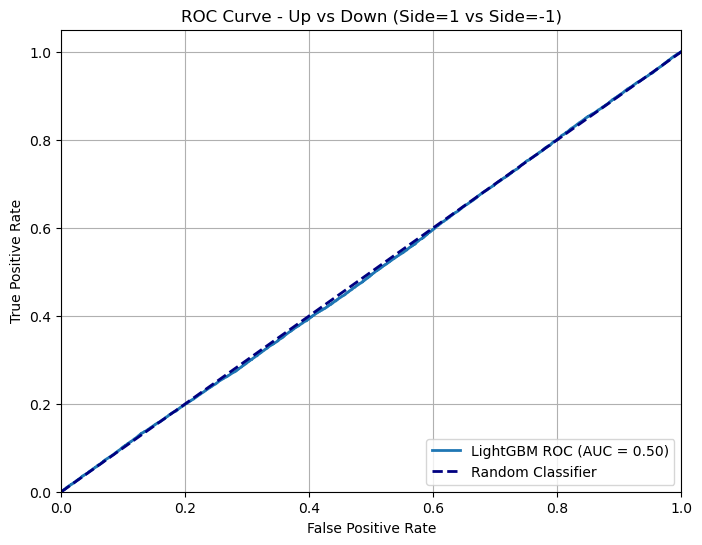

In [221]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# 映射：原始 Side (-1,0,1) <-> 模型标签 (0,1,2)
mapping     = {-1: 0, 0: 1, 1: 2}
inv_mapping = {0: -1, 1: 0, 2: 1}

# 1. LightGBM 预测各类概率 (0/1/2)
y_pred_proba_all = lgbm_final.predict_proba(X_test)   # shape: (n_samples, 3)

# 2. 把真实标签从 0/1/2 映射回原始 Side(-1/0/1)
y_test_side = np.vectorize(inv_mapping.get)(y_test)   # -> -1 / 0 / 1

# 3. 只保留有方向的样本（-1 或 1），构造二分类标签：Up vs Down
mask = (y_test_side != 0)         # 如果本来就没有 0，这里就是全部 True
y_side_binary = y_test_side[mask]

# 正类：上涨 Side = 1；负类：下跌 Side = -1
y_true_up = (y_side_binary == 1).astype(int)   # up=1, down=0

# 4. 对应的预测概率：P(Side=1) = P(class=2)
p_up = y_pred_proba_all[mask, mapping[1]]      # mapping[1] = 2

# 5. 计算 ROC 曲线 & AUC
fpr, tpr, thresholds = roc_curve(y_true_up, p_up)
roc_auc = auc(fpr, tpr)
print(f"AUC (Up vs Down) = {roc_auc:.4f}")

# 6. 画 ROC 曲线
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'LightGBM ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Up vs Down (Side=1 vs Side=-1)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
#Comment
#To assess the directional classification ability of the LightGBM model, we compute a ROC curve on a strictly binary task, 
#distinguishing up vs. down events. Specifically, we restrict the out-of-sample sample to observations with Side∈{−1,1},
#treat Side=1 (up) as the positive class and Side=−1 (down) as the negative class, and use the model-implied probability 
#P(Side=1) as the score. The resulting ROC curve lies essentially on the 45° diagonal, with an AUC of 0.498, which is 
#statistically indistinguishable from a random classifier. This indicates that, for single-event up‐vs‐down direction, 
#the LightGBM model has very limited ranking power—it does not systematically assign higher scores to eventual “up” events 
#than to “down” events. Combined with the positive portfolio-level Sharpe ratio observed in the backtest, this suggests that
#the model’s economic value arises more from cross-sectional filtering and risk control (e.g., avoiding very poor trades when 
#used in a long–short, multi-asset setting) rather than from strong directional discrimination on individual events.